<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/feature%2FCNN/notebooks/prova_vgg16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone -b feature/CNN https://github.com/dokunoale/chagas.git
!pip install -r chagas/requirements.txt

# Download the dataset
import gdown

url = "https://drive.google.com/file/d/1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC/view?usp=drive_link"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q /content/dataset.zip -d chagas/data/

Cloning into 'chagas'...
remote: Enumerating objects: 415, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 415 (delta 64), reused 76 (delta 29), pack-reused 270 (from 1)
Receiving objects: 100% (415/415), 4.89 MiB | 21.67 MiB/s, done.
Resolving deltas: 100% (188/188), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 26.8 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
  Attempting uninstall: h5py
    Found existing installation: h5py 3.14.0
    Uninstalling h5py-3.14.0:
      Successfully uninstalled h5py-3.14.0
  Attempting uninstall: scikit-learn

Downloading...
From (original): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC
From (redirected): https://drive.google.com/uc?id=1vK_gMI36xjdtiJjMBV7dKHurIExQs4hC&confirm=t&uuid=766981f7-201a-4680-ae49-df802ee486ed
To: /content/dataset.zip
100%|██████████| 623M/623M [00:02<00:00, 216MB/s]


In [2]:
import sys
sys.path.append("/content/chagas/src")

import os

import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import AUC

import numpy as np
from sklearn.model_selection import train_test_split
from scipy.signal import iirnotch, butter, filtfilt

from preprocessing.tf_dataset_loader import load_dataset, concatenate_and_shuffle
from models.layers import LightLogSpectrogram
from preprocessing.denoiser import *
from models.utils import *

In [3]:
data_path = "/content/chagas/data/big_splitted_dataset/"

X_train, y_train = concatenate_and_shuffle(
    load_dataset(data_path + "train/positives"),
    load_dataset(data_path + "train/negatives"))

X_val, y_val = concatenate_and_shuffle(
    load_dataset(data_path + "val/positives"),
    load_dataset(data_path + "val/negatives"))

X_test, y_test = concatenate_and_shuffle(
    load_dataset(data_path + "test/positives"),
    load_dataset(data_path + "test/negatives"))

In [4]:
X_train = filtfilt_noise_reduction(X_train, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_val = filtfilt_noise_reduction(X_val, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)
X_test = filtfilt_noise_reduction(X_test, fs=400, iir_freq=60.0, butterworth_cutoff=5., lowpass_cutoff=60.)

In [6]:
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

# Modello

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Input
input_shape = (2800, 12)
input_layer = layers.Input(shape=input_shape)

#Spettrogramma
x = LightLogSpectrogram()(input_layer)  # Output: (88, 64, 12)

# Step 1: Riduci da 12 a 3 canali (Conv2D 1x1)
x = layers.Conv2D(3, (1, 1), activation='relu')(x)  # Output: (88, 64, 3)

# Step 2: Resize a (224, 224, 3)
x = layers.Resizing(224, 224)(x)  # Output: (224, 224, 3)

# Step 3: Preprocessing per VGG16
x = layers.Lambda(preprocess_input)(x)

# Step 4: VGG16 preaddestrata (senza classificatore finale)
vgg_base = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
vgg_base.trainable = False  # Congela i pesi

x = vgg_base(x)
x = layers.GlobalAveragePooling2D()(x)

# Step 5: Classificazione finale (es. binaria)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)  # Cambia se multi-classe

# Costruisci il modello completo
model = models.Model(inputs=input_layer, outputs=output)

# Compila
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2800, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_log_spectrogram           │ (None, 88, 64, 12)     │             0 │
│ (LightLogSpectrogram)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 88, 64, 3)      │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,520 (56.38 MB)

 Trainable params: 65,832 (257.16 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

model.summary()

# Callback: early stopping e salvataggio del modello migliore
callbacks = make_callback("simple_CNN")

# Training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=30,
    callbacks=callbacks
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2800, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_log_spectrogram           │ (None, 88, 64, 12)     │             0 │
│ (LightLogSpectrogram)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 88, 64, 3)      │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,520 (56.38 MB)

 Trainable params: 65,832 (257.16 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5612 - auc: 0.5771 - loss: 0.7327
Epoch 1: val_auc improved from -inf to 0.67107, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 46s 110ms/step - accuracy: 0.5614 - auc: 0.5772 - loss: 0.7326 - val_accuracy: 0.6114 - val_auc: 0.6711 - val_loss: 0.6469 - learning_rate: 0.0010
Epoch 2/50
261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6229 - auc: 0.6622 - loss: 0.6508
Epoch 2: val_auc improved from 0.67107 to 0.68085, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6229 - auc: 0.6622 - loss: 0.6508 - val_accuracy: 0.6212 - val_auc: 0.6808 - val_loss: 0.6410 - learning_rate: 0.0010
Epoch 3/50
261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6228 - auc: 0.6651 - loss: 0.6493
Epoch 3: val_auc improved from 0.68085 to 0.68641, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6228 - 

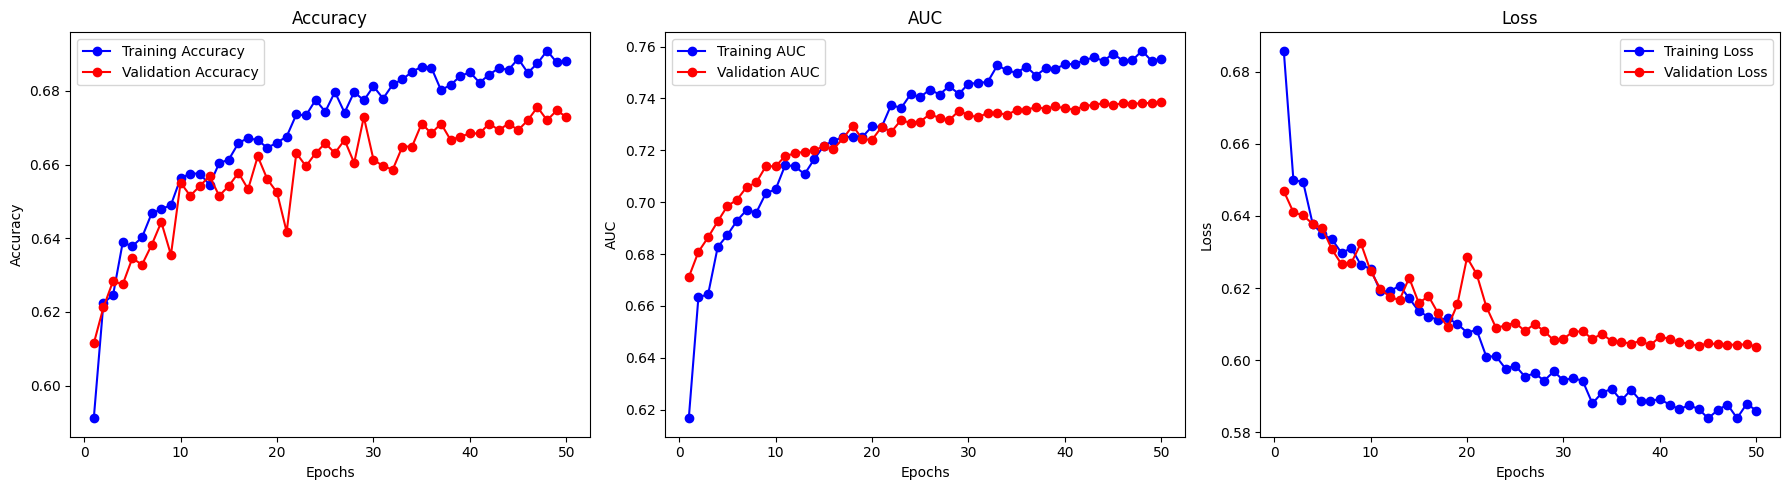

In [9]:
plot_training_metrics(history)

# Modello 2: passiamo le 12 lead separatamente

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Funzione per creare un branch VGG16
def create_vgg_branch():
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False  # Congeliamo i pesi di VGG16
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D()
    ])
    return model

# Input originale: 12 spettrogrammi di forma (88, 64)
input_layer = layers.Input(shape=(2800, 12))  # (batch, H, W, channels)
x = LightLogSpectrogram()(input_layer)  # Output: (88, 64, 12)

# Lista per raccogliere le features di ogni canale
features = []

for i in range(12):
    # Estrai lo spettrogramma i-esimo: shape (88, 64, 1)
    single_spectrogram = layers.Lambda(lambda x: tf.expand_dims(x[:,:,:,i], axis=-1))(x)

    # Resize a (224, 224, 1) → poi duplicato a (224, 224, 3)
    resized = layers.Resizing(224, 224)(single_spectrogram)
    rgb = layers.Concatenate(axis=-1)([resized, resized, resized])  # Da (224, 224, 1) → (224, 224, 3)

    # Preprocessing per VGG16
    preprocessed = layers.Lambda(preprocess_input)(rgb)

    # Passa attraverso VGG16 branch (senza testa)
    vgg_branch = create_vgg_branch()
    feat = vgg_branch(preprocessed)  # Output: feature vector

    features.append(feat)

# Combina le feature dei 12 canali (es. concatenazione)
combined_features = layers.Concatenate()(features)

# Classificazione finale
x = layers.Dense(256, activation='relu')(combined_features)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)

# Costruisci il modello completo
model2 = models.Model(inputs=input_layer, outputs=output)

In [11]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

model2.summary()

# Callback: early stopping e salvataggio del modello migliore
callbacks = make_callback("simple_CNN")

# Training
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=30,
    callbacks=callbacks
)

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 2800, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ light_log_spectrog… │ (None, 88, 64,    │          0 │ input_layer_2[0]… │
│ (LightLogSpectrogr… │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_13 (Lambda)  │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_15 (Lambda)  │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_17 (Lambda)  │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_19 (Lambda)  │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_21 (Lambda)  │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_23 (Lambda)  │ (None, 88, 64, 1) │          0 │ light_log_spectr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_1          │ (None, 224, 224,  │          0 │ lambda_1[0][0]    │
│ (Resizing)          │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_2          │ (None, 224, 224,  │          0 │ lambda_3[0][0]    │
│ (Resizing)          │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_3          │ (None, 224, 224,  │          0 │ lambda_5[0][0]    │
│ (Resizing)          │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_4          │ (None, 224, 224,  │          0 │ lambda_7[0][0]    │
│ (Resizing)          │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_5          │ (None, 224, 224,  │          0 │ lambda_9[0][0]    │
│ (Resizing)          │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_6          │ (None, 224, 224,  │          0 │ lambda_11[0][0]   │
│ (Resizing)          │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_7          │ (None, 224, 224,  │          0 │ lambda_13[0][0] 

 Total params: 178,165,889 (679.65 MB)

 Trainable params: 1,589,633 (6.06 MB)

 Non-trainable params: 176,576,256 (673.58 MB)

Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5507 - auc: 0.5572 - loss: 0.8590
Epoch 1: val_auc improved from -inf to 0.64336, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 77s 236ms/step - accuracy: 0.5507 - auc: 0.5573 - loss: 0.8585 - val_accuracy: 0.5722 - val_auc: 0.6434 - val_loss: 0.6773 - learning_rate: 0.0010
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5738 - auc: 0.6090 - loss: 0.6768
Epoch 2: val_auc improved from 0.64336 to 0.66140, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 44s 168ms/step - accuracy: 0.5738 - auc: 0.6090 - loss: 0.6768 - val_accuracy: 0.5615 - val_auc: 0.6614 - val_loss: 0.6736 - learning_rate: 0.0010
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5862 - auc: 0.6249 - loss: 0.6677
Epoch 3: val_auc improved from 0.66140 to 0.67049, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 44s 169ms/step - accuracy: 0.58

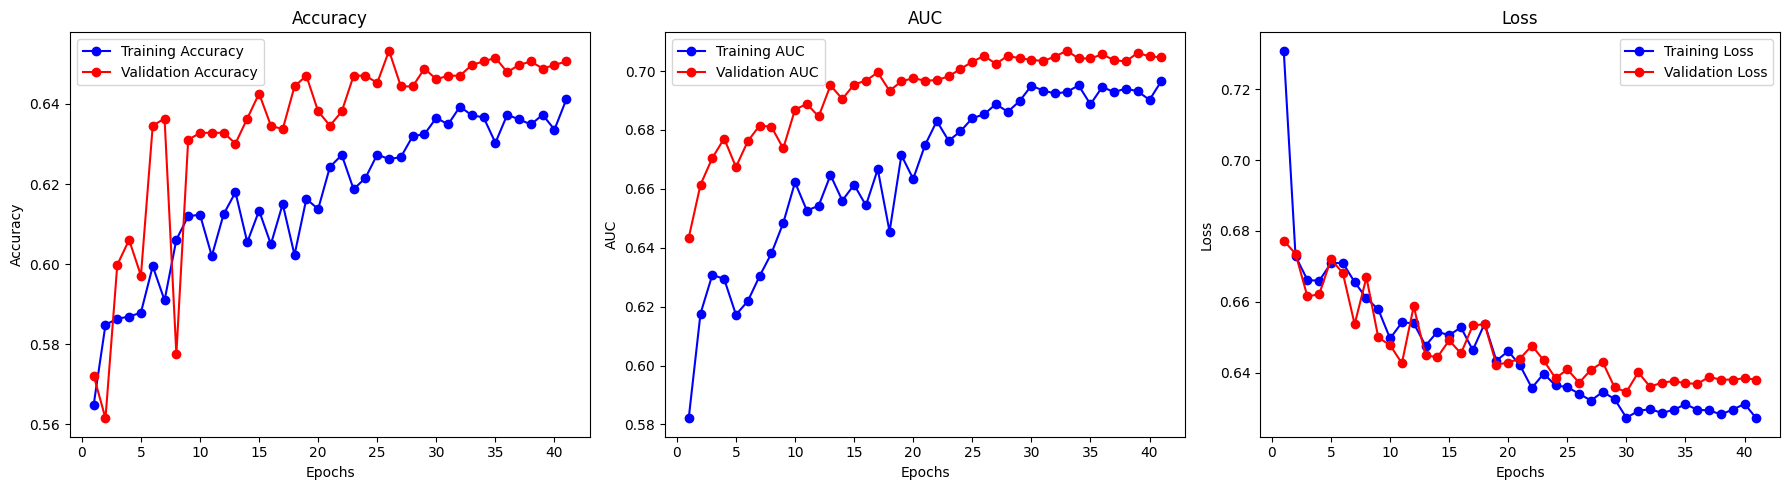

In [15]:
plot_training_metrics(history2)

# Modello custom ispirato a VGG

In [12]:
from re import L

input_layer = layers.Input(shape=(2800, 12))

x = LightLogSpectrogram()(input_layer)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)

model3 = models.Model(inputs=input_layer, outputs=output)

In [14]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

model3.summary()

# Callback: early stopping e salvataggio del modello migliore
callbacks = make_callback("simple_CNN")

# Training
history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=30,
    callbacks=callbacks
)

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 2800, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_log_spectrogram_2         │ (None, 88, 64, 12)     │             0 │
│ (LightLogSpectrogram)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 88, 64, 32)     │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 44, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 44, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,481 (439.38 KB)

 Trainable params: 112,481 (439.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5253 - auc: 0.5338 - loss: 0.6956
Epoch 1: val_auc improved from -inf to 0.65552, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.5254 - auc: 0.5339 - loss: 0.6956 - val_accuracy: 0.5080 - val_auc: 0.6555 - val_loss: 0.6892 - learning_rate: 0.0010
Epoch 2/50
261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6192 - auc: 0.6793 - loss: 0.6494
Epoch 2: val_auc improved from 0.65552 to 0.75962, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6195 - auc: 0.6794 - loss: 0.6492 - val_accuracy: 0.6159 - val_auc: 0.7596 - val_loss: 0.6492 - learning_rate: 0.0010
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6789 - auc: 0.7376 - loss: 0.6050
Epoch 3: val_auc improved from 0.75962 to 0.79521, saving model to simple_CNN_best_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6790 - auc: 0.

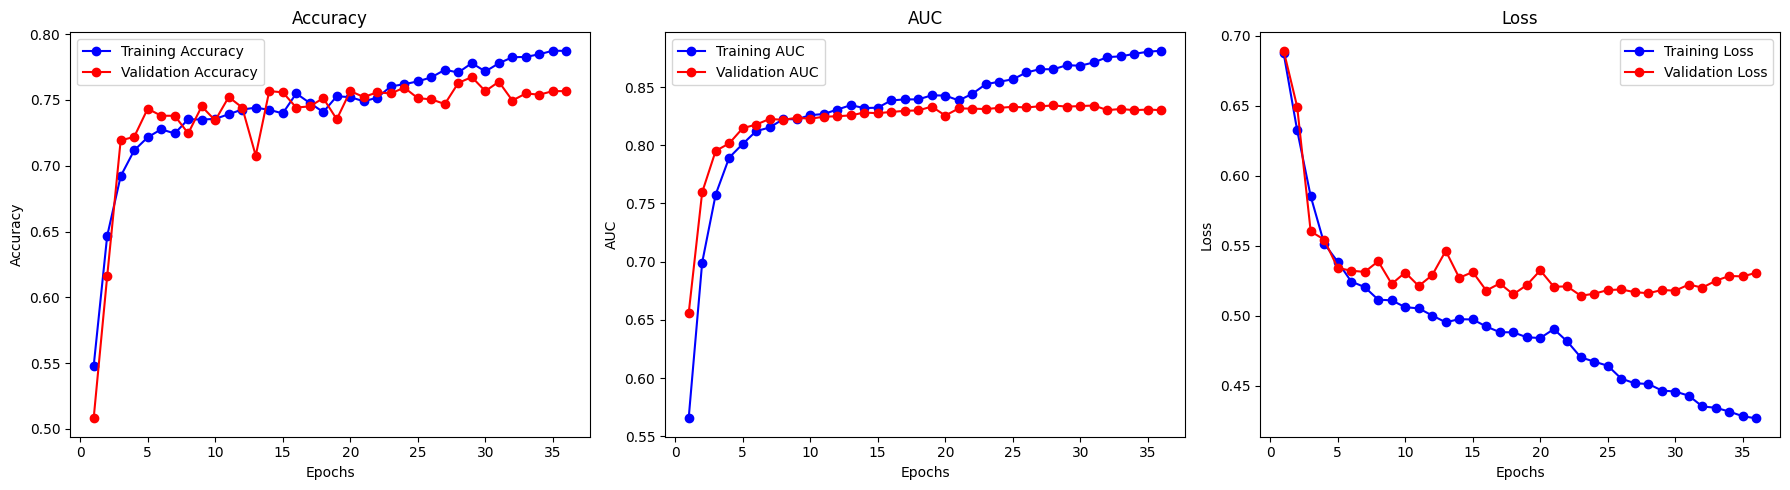

In [16]:
plot_training_metrics(history3)